In [79]:
!pip install pandas numpy matplotlib seaborn statsmodels tensorflow xgboost scikit-learn



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [80]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import tensorflow as tf
import os
import warnings
from tensorflow.keras.layers import Dense, LSTM, Conv1D, MaxPooling1D, TimeDistributed, Flatten, Dropout, RepeatVector
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss, ccf
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from math import sqrt

%matplotlib inline

In [81]:
dfWeather = pd.read_csv(
    'final_weather_features.csv', 
    parse_dates=['dt_iso']
)


dfEnergy = pd.read_csv(
    "final_energy_dataset.csv", 
    parse_dates=['time']
)

In [82]:
dfEnergy.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation marine,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2019-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,NaN,863.0,1051.0,1899.0,0.0,7096.0,43.0,73.0,49.0,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2019-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,NaN,920.0,1009.0,1658.0,0.0,7096.0,43.0,71.0,50.0,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2019-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,NaN,1164.0,973.0,1371.0,0.0,7099.0,43.0,73.0,50.0,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2019-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,NaN,1503.0,949.0,779.0,0.0,7098.0,43.0,75.0,50.0,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2019-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,NaN,1826.0,953.0,720.0,0.0,7097.0,43.0,74.0,42.0,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


drop unuseable columns

In [83]:
dfEnergy = dfEnergy.drop(['generation fossil coal-derived gas','generation fossil oil shale', 
                            'generation fossil peat', 'generation geothermal', 
                            'generation hydro pumped storage aggregated', 'generation marine', 
                            'generation wind offshore', 'forecast wind offshore eday ahead',
                            'total load forecast', 'forecast solar day ahead',
                            'forecast wind onshore day ahead'], 
                            axis=1)

In [84]:
dfEnergy.describe().round(1)

,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,total load actual,price day ahead,price actual
count,35045.0,35046.0,35046.0,35046.0,35045.0,35045.0,35045.0,35046.0,35047.0,35046.0,35046.0,35046.0,35045.0,35046.0,35028.0,35064.0,35064.0
mean,383.5,448.1,5622.7,4256.1,298.3,475.6,972.1,2605.1,6263.9,60.2,85.6,1432.7,269.5,5464.5,28696.9,49.9,57.9
std,85.4,354.6,2201.8,1961.6,52.5,792.4,400.8,1835.2,839.7,20.2,14.1,1680.1,50.2,3213.7,4575.0,14.6,14.2
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18041.0,2.1,9.3
25%,333.0,0.0,4126.0,2527.0,263.0,0.0,637.0,1077.2,5760.0,53.0,73.0,71.0,240.0,2933.0,24807.8,41.5,49.3
50%,367.0,509.0,4969.0,4474.0,300.0,68.0,906.0,2164.0,6566.0,57.0,88.0,616.0,279.0,4849.0,28901.0,50.5,58.0
75%,433.0,757.0,6429.0,5838.8,330.0,616.0,1250.0,3757.0,7025.0,80.0,97.0,2578.0,310.0,7398.0,32192.0,60.5,68.0
max,592.0,999.0,20034.0,8359.0,449.0,4523.0,2000.0,9728.0,7117.0,106.0,119.0,5792.0,357.0,17436.0,41015.0,102.0,116.8


In [85]:
dfEnergy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   time                                         35064 non-null  object 
 1   generation biomass                           35045 non-null  float64
 2   generation fossil brown coal/lignite         35046 non-null  float64
 3   generation fossil gas                        35046 non-null  float64
 4   generation fossil hard coal                  35046 non-null  float64
 5   generation fossil oil                        35045 non-null  float64
 6   generation hydro pumped storage consumption  35045 non-null  float64
 7   generation hydro run-of-river and poundage   35045 non-null  float64
 8   generation hydro water reservoir             35046 non-null  float64
 9   generation nuclear                           35047 non-null  float64
 10

In [86]:
dfEnergy.index = pd.to_datetime(dfEnergy['time'], utc=True, infer_datetime_format=True)
dfEnergy.drop(columns='time', inplace=True)


In [87]:
missing_values = dfEnergy.isnull().sum().sum()
duplicate_rows = dfEnergy.duplicated(keep='first').sum()
print(missing_values)
print(duplicate_rows)
dfEnergy.isnull().sum(axis=0)

292
0


generation biomass                             19
generation fossil brown coal/lignite           18
generation fossil gas                          18
generation fossil hard coal                    18
generation fossil oil                          19
generation hydro pumped storage consumption    19
generation hydro run-of-river and poundage     19
generation hydro water reservoir               18
generation nuclear                             17
generation other                               18
generation other renewable                     18
generation solar                               18
generation waste                               19
generation wind onshore                        18
total load actual                              36
price day ahead                                 0
price actual                                    0
dtype: int64

In [88]:
dfEnergy.interpolate(method='linear', limit_direction='forward', inplace=True, axis=0)

In [89]:
dfEnergy.isnull().sum(axis=0)

generation biomass                             0
generation fossil brown coal/lignite           0
generation fossil gas                          0
generation fossil hard coal                    0
generation fossil oil                          0
generation hydro pumped storage consumption    0
generation hydro run-of-river and poundage     0
generation hydro water reservoir               0
generation nuclear                             0
generation other                               0
generation other renewable                     0
generation solar                               0
generation waste                               0
generation wind onshore                        0
total load actual                              0
price day ahead                                0
price actual                                   0
dtype: int64

In [90]:
dfWeather.tail(5)

,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
178391,2022-12-31 19:00:00+01:00,Seville,287.76,287.15,288.15,1028,54,3,30,0.0,0.0,0.0,0,800,clear,sky is clear,01n
178392,2022-12-31 20:00:00+01:00,Seville,285.76,285.15,286.15,1029,62,3,30,0.0,0.0,0.0,0,800,clear,sky is clear,01n
178393,2022-12-31 21:00:00+01:00,Seville,285.15,285.15,285.15,1028,58,4,50,0.0,0.0,0.0,0,800,clear,sky is clear,01n
178394,2022-12-31 22:00:00+01:00,Seville,284.15,284.15,284.15,1029,57,4,60,0.0,0.0,0.0,0,800,clear,sky is clear,01n
178395,2022-12-31 23:00:00+01:00,Seville,283.97,282.15,285.15,1029,70,3,50,0.0,0.0,0.0,0,800,clear,sky is clear,01n


In [91]:
dfWeather.describe().round(1)

,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id
count,178396.0,178396.0,178396.0,178396.0,178396.0,178396.0,178396.0,178396.0,178396.0,178396.0,178396.0,178396.0
mean,289.6,288.3,291.1,1069.3,68.4,2.5,166.6,0.1,0.0,0.0,25.1,759.8
std,8.0,8.0,8.6,5969.6,21.9,2.1,116.6,0.4,0.0,0.2,30.8,108.7
min,262.2,262.2,262.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,200.0
25%,283.7,282.5,284.6,1013.0,53.0,1.0,55.0,0.0,0.0,0.0,0.0,800.0
50%,289.2,288.2,290.2,1018.0,72.0,2.0,177.0,0.0,0.0,0.0,20.0,800.0
75%,295.2,293.7,297.2,1022.0,87.0,4.0,270.0,0.0,0.0,0.0,40.0,801.0
max,315.6,315.2,321.2,1008371.0,100.0,133.0,360.0,12.0,2.3,21.5,100.0,804.0


In [92]:
dfWeather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178396 entries, 0 to 178395
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   dt_iso               178396 non-null  object 
 1   city_name            178396 non-null  object 
 2   temp                 178396 non-null  float64
 3   temp_min             178396 non-null  float64
 4   temp_max             178396 non-null  float64
 5   pressure             178396 non-null  int64  
 6   humidity             178396 non-null  int64  
 7   wind_speed           178396 non-null  int64  
 8   wind_deg             178396 non-null  int64  
 9   rain_1h              178396 non-null  float64
 10  rain_3h              178396 non-null  float64
 11  snow_3h              178396 non-null  float64
 12  clouds_all           178396 non-null  int64  
 13  weather_id           178396 non-null  int64  
 14  weather_main         178396 non-null  object 
 15  weather_descripti

In [93]:
intCols = dfWeather.select_dtypes(include=[np.int64]).columns
dfWeather[intCols] = dfWeather[intCols].astype(np.float64)


In [94]:
dfWeather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178396 entries, 0 to 178395
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   dt_iso               178396 non-null  object 
 1   city_name            178396 non-null  object 
 2   temp                 178396 non-null  float64
 3   temp_min             178396 non-null  float64
 4   temp_max             178396 non-null  float64
 5   pressure             178396 non-null  float64
 6   humidity             178396 non-null  float64
 7   wind_speed           178396 non-null  float64
 8   wind_deg             178396 non-null  float64
 9   rain_1h              178396 non-null  float64
 10  rain_3h              178396 non-null  float64
 11  snow_3h              178396 non-null  float64
 12  clouds_all           178396 non-null  float64
 13  weather_id           178396 non-null  float64
 14  weather_main         178396 non-null  object 
 15  weather_descripti

In [95]:
dfWeather['time'] = pd.to_datetime(dfWeather['dt_iso'], utc=True, infer_datetime_format=True)
dfWeather = dfWeather.drop(['dt_iso'], axis=1)
dfWeather = dfWeather.set_index('time')


In [96]:
missing_values = dfWeather.isnull().sum().sum()
duplicate_rows = dfWeather.duplicated(keep='first').sum()
print(missing_values)
print(duplicate_rows)
dfWeather.isnull().sum(axis=0)

0
8622


city_name              0
temp                   0
temp_min               0
temp_max               0
pressure               0
humidity               0
wind_speed             0
wind_deg               0
rain_1h                0
rain_3h                0
snow_3h                0
clouds_all             0
weather_id             0
weather_main           0
weather_description    0
weather_icon           0
dtype: int64

In [97]:
tempDf1 = dfWeather.reset_index()
tempDf1.drop_duplicates(subset=['time', 'city_name'], keep='last', inplace=True)
dfWeather2 = tempDf1.set_index('time')

tempDf2 = dfWeather.reset_index()
tempDf2.drop_duplicates(subset=['time', 'city_name'], keep='first', inplace=True)
dfWeather = tempDf2.set_index('time')


In [98]:
duplicate_rows = dfWeather.duplicated(keep='first').sum()
print(duplicate_rows)

8587


In [99]:
print(dfEnergy.shape[0])

35064


In [100]:
dfWeather = dfWeather.drop(['weather_main', 'weather_id', 
                              'weather_description', 'weather_icon'], axis=1)

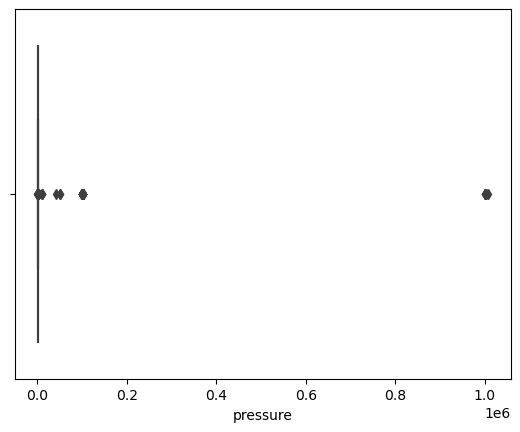

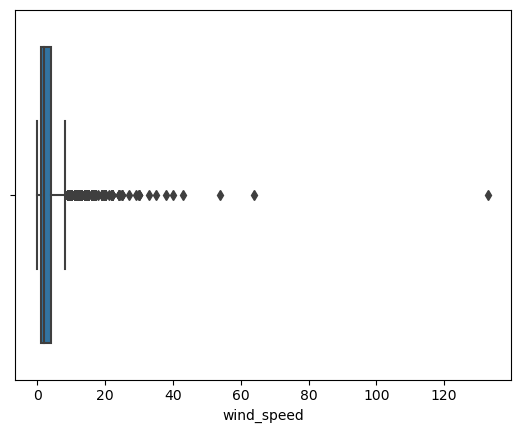

In [101]:
sns.boxplot(x=dfWeather['pressure'])
plt.show()
sns.boxplot(x=dfWeather['wind_speed'])
plt.show()

In [102]:
dfWeather.loc[dfWeather.pressure > 1050, 'pressure'] = np.nan
dfWeather.loc[dfWeather.pressure < 930, 'pressure'] = np.nan
dfWeather.loc[dfWeather.wind_speed > 50, 'wind_speed'] = np.nan

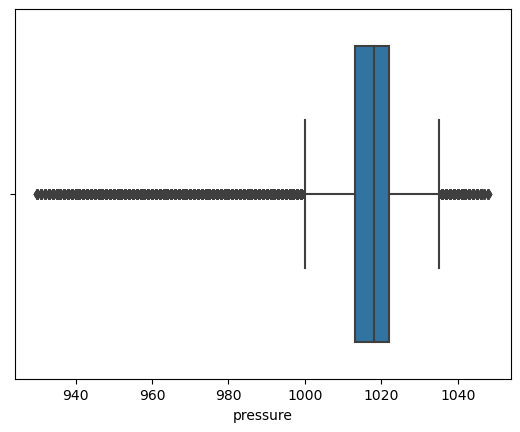

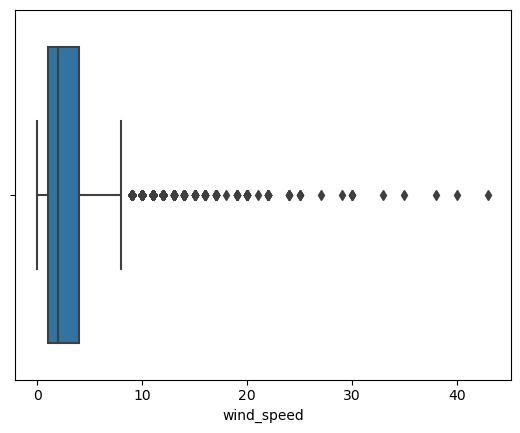

In [103]:
sns.boxplot(x=dfWeather['pressure'])
plt.show()
sns.boxplot(x=dfWeather['wind_speed'])
plt.show()

In [104]:
dfWeather.interpolate(method='linear', limit_direction='forward', inplace=True, axis=0)

In [105]:
df_1, df_2, df_3, df_4, df_5 = [x for _, x in dfWeather.groupby('city_name')]
dfs = [df_1, df_2, df_3, df_4, df_5]


In [106]:
dfFinal = dfEnergy

for df in dfs:
    city = df['city_name'].unique()
    city_str = str(city).replace("'", "").replace('[', '').replace(']', '').replace(' ', '')
    df = df.add_suffix('_{}'.format(city_str))
    dfFinal = dfFinal.merge(df, on=['time'], how='outer')
    dfFinal = dfFinal.drop('city_name_{}'.format(city_str), axis=1)
    
dfFinal.columns

Index(['generation biomass', 'generation fossil brown coal/lignite',
       'generation fossil gas', 'generation fossil hard coal',
       'generation fossil oil', 'generation hydro pumped storage consumption',
       'generation hydro run-of-river and poundage',
       'generation hydro water reservoir', 'generation nuclear',
       'generation other', 'generation other renewable', 'generation solar',
       'generation waste', 'generation wind onshore', 'total load actual',
       'price day ahead', 'price actual', 'temp_Barcelona',
       'temp_min_Barcelona', 'temp_max_Barcelona', 'pressure_Barcelona',
       'humidity_Barcelona', 'wind_speed_Barcelona', 'wind_deg_Barcelona',
       'rain_1h_Barcelona', 'rain_3h_Barcelona', 'snow_3h_Barcelona',
       'clouds_all_Barcelona', 'temp_Lyon', 'temp_min_Lyon', 'temp_max_Lyon',
       'pressure_Lyon', 'humidity_Lyon', 'wind_speed_Lyon', 'wind_deg_Lyon',
       'rain_1h_Lyon', 'rain_3h_Lyon', 'snow_3h_Lyon', 'clouds_all_Lyon',
       'temp

In [107]:
dfFinal.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35064 entries, 2018-12-31 23:00:00+00:00 to 2022-12-31 22:00:00+00:00
Data columns (total 72 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   generation biomass                           35064 non-null  float64
 1   generation fossil brown coal/lignite         35064 non-null  float64
 2   generation fossil gas                        35064 non-null  float64
 3   generation fossil hard coal                  35064 non-null  float64
 4   generation fossil oil                        35064 non-null  float64
 5   generation hydro pumped storage consumption  35064 non-null  float64
 6   generation hydro run-of-river and poundage   35064 non-null  float64
 7   generation hydro water reservoir             35064 non-null  float64
 8   generation nuclear                           35064 non-null  float64
 9   generation other         

In [108]:
print(dfFinal.isnull().values.sum())
print( dfFinal.duplicated(keep='first').sum())

0
0


In [109]:
dfFinal.head()


,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,total load actual,price day ahead,price actual,temp_Barcelona,temp_min_Barcelona,temp_max_Barcelona,pressure_Barcelona,humidity_Barcelona,wind_speed_Barcelona,wind_deg_Barcelona,rain_1h_Barcelona,rain_3h_Barcelona,snow_3h_Barcelona,clouds_all_Barcelona,temp_Lyon,temp_min_Lyon,temp_max_Lyon,pressure_Lyon,humidity_Lyon,wind_speed_Lyon,wind_deg_Lyon,rain_1h_Lyon,rain_3h_Lyon,snow_3h_Lyon,clouds_all_Lyon,temp_Marseille,temp_min_Marseille,temp_max_Marseille,pressure_Marseille,humidity_Marseille,wind_speed_Marseille,wind_deg_Marseille,rain_1h_Marseille,rain_3h_Marseille,snow_3h_Marseille,clouds_all_Marseille,temp_Paris,temp_min_Paris,temp_max_Paris,pressure_Paris,humidity_Paris,wind_speed_Paris,wind_deg_Paris,rain_1h_Paris,rain_3h_Paris,snow_3h_Paris,clouds_all_Paris,temp_Seville,temp_min_Seville,temp_max_Seville,pressure_Seville,humidity_Seville,wind_speed_Seville,wind_deg_Seville,rain_1h_Seville,rain_3h_Seville,snow_3h_Seville,clouds_all_Seville
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-12-31 23:00:00+00:00,447.0,329.0,4844.0,4821.0,162.0,863.0,1051.0,1899.0,7096.0,43.0,73.0,49.0,196.0,6378.0,25385.0,50.10,65.41,281.625,281.625,281.625,1035.0,100.0,7.0,58.0,0.0,0.0,0.0,0.0,267.325,267.325,267.325,971.0,63.0,1.0,309.0,0.0,0.0,0.0,0.0,270.475,270.475,270.475,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,0.0,269.657312,269.657312,269.657312,1036.0,97.0,0.0,226.0,0.0,0.0,0.0,0.0,273.375,273.375,273.375,1039.0,75.0,1.0,21.0,0.0,0.0,0.0,0.0
2019-01-01 00:00:00+00:00,449.0,328.0,5196.0,4755.0,158.0,920.0,1009.0,1658.0,7096.0,43.0,71.0,50.0,195.0,5890.0,24382.0,48.10,64.92,281.625,281.625,281.625,1035.0,100.0,7.0,58.0,0.0,0.0,0.0,0.0,267.325,267.325,267.325,971.0,63.0,1.0,309.0,0.0,0.0,0.0,0.0,270.475,270.475,270.475,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,0.0,269.763500,269.763500,269.763500,1035.0,97.0,0.0,229.0,0.0,0.0,0.0,0.0,273.375,273.375,273.375,1039.0,75.0,1.0,21.0,0.0,0.0,0.0,0.0
2019-01-01 01:00:00+00:00,448.0,323.0,4857.0,4581.0,157.0,1164.0,973.0,1371.0,7099.0,43.0,73.0,50.0,196.0,5461.0,22734.0,47.33,64.48,281.286,281.286,281.286,1036.0,100.0,7.0,48.0,0.0,0.0,0.0,0.0,266.186,266.186,266.186,971.0,64.0,1.0,273.0,0.0,0.0,0.0,0.0,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0,269.251688,269.251688,269.251688,1036.0,97.0,1.0,224.0,0.0,0.0,0.0,0.0,274.086,274.086,274.086,1039.0,71.0,3.0,27.0,0.0,0.0,0.0,0.0
2019-01-01 02:00:00+00:00,438.0,254.0,4314.0,4131.0,160.0,1503.0,949.0,779.0,7098.0,43.0,75.0,50.0,191.0,5238.0,21286.0,42.27,59.32,281.286,281.286,281.286,1036.0,100.0,7.0,48.0,0.0,0.0,0.0,0.0,266.186,266.186,266.186,971.0,64.0,1.0,273.0,0.0,0.0,0.0,0.0,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0,269.203344,269.203344,269.203344,1035.0,97.0,1.0,225.0,0.0,0.0,0.0,0.0,274.086,274.086,274.086,1039.0,71.0,3.0,27.0,0.0,0.0,0.0,0.0
2019-01-01 03:00:00+00:00,428.0,187.0,4130.0,3840.0,156.0,1826.0,953.0,720.0,7097.0,43.0,74.0,42.0,189.0,4935.0,20264.0,38.41,56.04,281.286,281.286,281.286,1036.0,100.0,7.0,48.0,0.0,0.0,0.0,0.0,266.186,266.186,266.186,971.0,64.0,1.0,273.0,0.0,0.0,0.0,0.0,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0,269.485500,269.485500,269.485500,1035.0,97.0,1.0,221.0,0.0,0.0,0.0,0.0,274.086,274.086,274.086,1039.0,71.0,3.0,27.0,0.0,0.0,0.0,0.0


In [110]:
cities = ['Barcelona', 'Paris', 'Lyon', 'Seville', 'Marseille']

for city in cities:
    dfFinal = dfFinal.drop(['rain_3h_{}'.format(city)], axis=1)

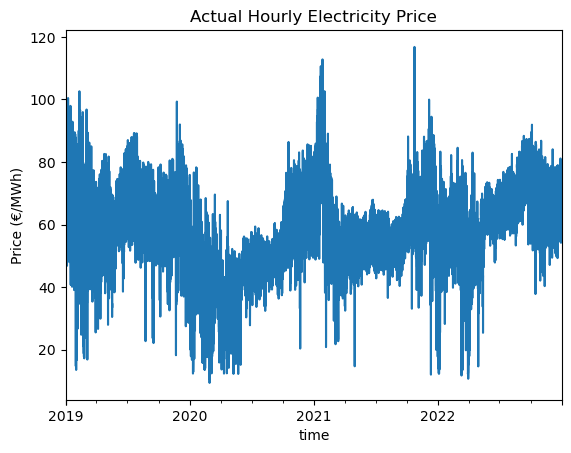

In [111]:
# If dfFinal['price_actual'] is a column you want to plot:
dfFinal['price actual'].plot(title='Actual Hourly Electricity Price', ylabel='Price (€/MWh)')
plt.show()


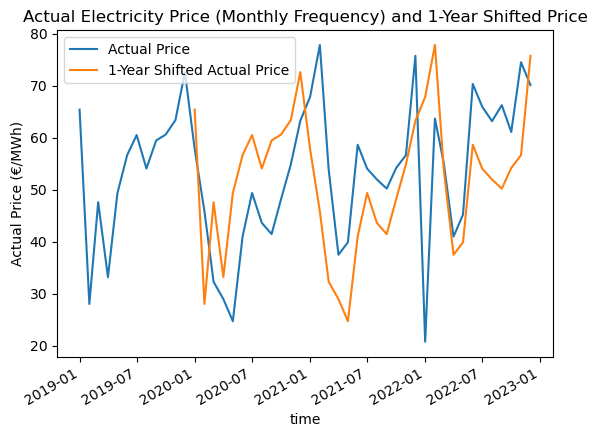

In [112]:
import matplotlib.pyplot as plt

# Resample to monthly frequency
monthlyPrice = dfFinal['price actual'].asfreq('M')

# Shift the series by 12 months
shifted = monthlyPrice.shift(12)

# Plot the monthly series
ax = monthlyPrice.plot(
    label='Actual Price',
    ylabel='Actual Price (€/MWh)',
    title='Actual Electricity Price (Monthly Frequency) and 1-Year Shifted Price'
)

# Plot the shifted (lagged) series on the same axes
shifted.plot(ax=ax, label='1-Year Shifted Actual Price')

# Add a legend and show the plot
ax.legend()
plt.show()


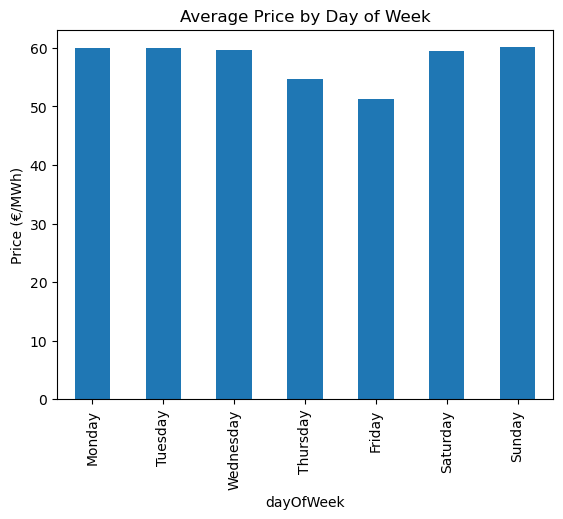

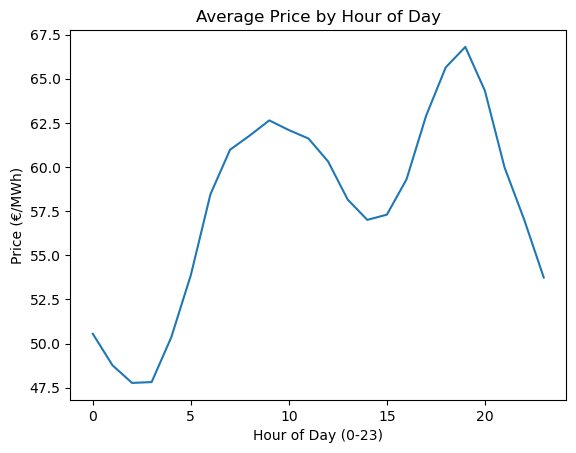

In [113]:
import pandas as pd
import matplotlib.pyplot as plt


dfFinal['dayOfWeek'] = dfFinal.index.day_name()

dayOfWeekAverages = dfFinal.groupby('dayOfWeek')['price actual'].mean()

dayOrder = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dayOfWeekAverages = dayOfWeekAverages.reindex(dayOrder)

dayOfWeekAverages.plot(kind='bar', title='Average Price by Day of Week', ylabel='Price (€/MWh)')
plt.show()


dfFinal['hourOfDay'] = dfFinal.index.hour

hourOfDayAverages = dfFinal.groupby('hourOfDay')['price actual'].mean()

hourOfDayAverages.plot(title='Average Price by Hour of Day', xlabel='Hour of Day (0-23)', ylabel='Price (€/MWh)')
plt.show()

dfFinal.drop(columns=['dayOfWeek', 'hourOfDay'], inplace=True)


PP-(phillips perron test

In [114]:
!pip install arch



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [115]:
from arch.unitroot import PhillipsPerron

# Run the Phillips-Perron test on the "price actual" series
pp_test = PhillipsPerron(dfFinal['price actual'])

print("Phillips-Perron Test Statistic:", pp_test.stat)
print("p-value:", pp_test.pvalue)
print("Lags used:", pp_test.lags)
print("Number of observations:", pp_test.nobs)



Phillips-Perron Test Statistic: -22.929431446380804
p-value: 0.0
Lags used: 52
Number of observations: 35063


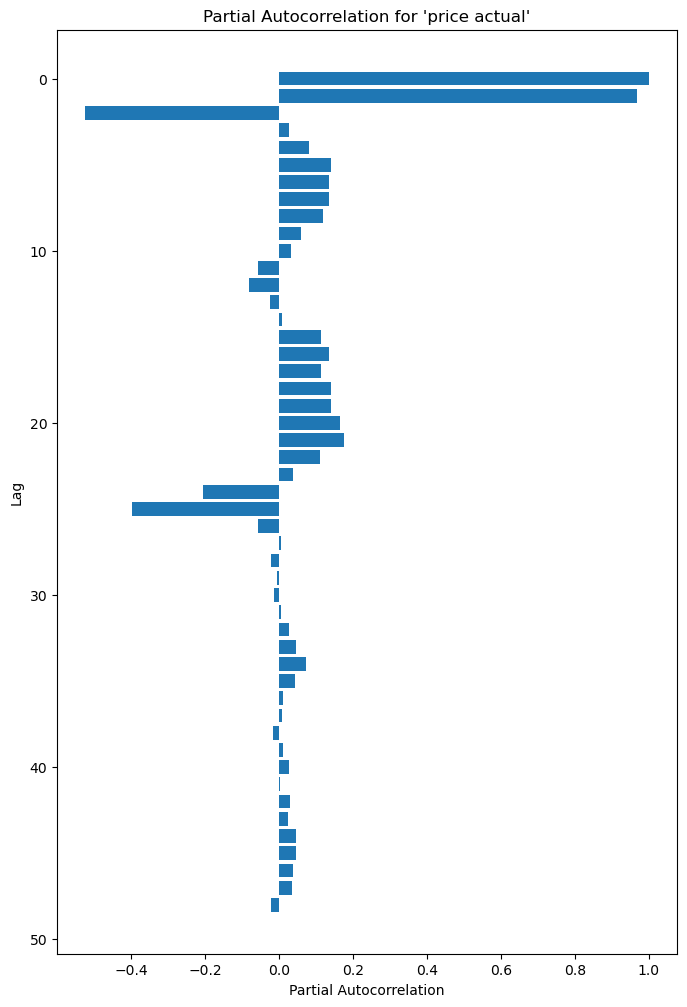

In [116]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import pacf

# Calculate PACF values for lags up to 48
pacfValues = pacf(dfFinal['price actual'], nlags=48)

# Create a list of lag numbers
lags = list(range(len(pacfValues)))

plt.figure(figsize=(8, 12))
plt.barh(lags, pacfValues, align='center')
plt.xlabel('Partial Autocorrelation')
plt.ylabel('Lag')
plt.title("Partial Autocorrelation for 'price actual'")
plt.gca().invert_yaxis() 
plt.show()


In [117]:
dfFinal = dfFinal.drop(['snow_3h_Barcelona', 'snow_3h_Seville'], axis=1)

In [118]:
dfFinal['hour'] = dfFinal.index.hour
dfFinal['weekday'] = dfFinal.index.weekday
dfFinal['month'] = dfFinal.index.month


In [119]:
dfFinal.head(5)

,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,total load actual,price day ahead,price actual,temp_Barcelona,temp_min_Barcelona,temp_max_Barcelona,pressure_Barcelona,humidity_Barcelona,wind_speed_Barcelona,wind_deg_Barcelona,rain_1h_Barcelona,clouds_all_Barcelona,temp_Lyon,temp_min_Lyon,temp_max_Lyon,pressure_Lyon,humidity_Lyon,wind_speed_Lyon,wind_deg_Lyon,rain_1h_Lyon,snow_3h_Lyon,clouds_all_Lyon,temp_Marseille,temp_min_Marseille,temp_max_Marseille,pressure_Marseille,humidity_Marseille,wind_speed_Marseille,wind_deg_Marseille,rain_1h_Marseille,snow_3h_Marseille,clouds_all_Marseille,temp_Paris,temp_min_Paris,temp_max_Paris,pressure_Paris,humidity_Paris,wind_speed_Paris,wind_deg_Paris,rain_1h_Paris,snow_3h_Paris,clouds_all_Paris,temp_Seville,temp_min_Seville,temp_max_Seville,pressure_Seville,humidity_Seville,wind_speed_Seville,wind_deg_Seville,rain_1h_Seville,clouds_all_Seville,hour,weekday,month
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-12-31 23:00:00+00:00,447.0,329.0,4844.0,4821.0,162.0,863.0,1051.0,1899.0,7096.0,43.0,73.0,49.0,196.0,6378.0,25385.0,50.10,65.41,281.625,281.625,281.625,1035.0,100.0,7.0,58.0,0.0,0.0,267.325,267.325,267.325,971.0,63.0,1.0,309.0,0.0,0.0,0.0,270.475,270.475,270.475,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,269.657312,269.657312,269.657312,1036.0,97.0,0.0,226.0,0.0,0.0,0.0,273.375,273.375,273.375,1039.0,75.0,1.0,21.0,0.0,0.0,23,0,12
2019-01-01 00:00:00+00:00,449.0,328.0,5196.0,4755.0,158.0,920.0,1009.0,1658.0,7096.0,43.0,71.0,50.0,195.0,5890.0,24382.0,48.10,64.92,281.625,281.625,281.625,1035.0,100.0,7.0,58.0,0.0,0.0,267.325,267.325,267.325,971.0,63.0,1.0,309.0,0.0,0.0,0.0,270.475,270.475,270.475,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,269.763500,269.763500,269.763500,1035.0,97.0,0.0,229.0,0.0,0.0,0.0,273.375,273.375,273.375,1039.0,75.0,1.0,21.0,0.0,0.0,0,1,1
2019-01-01 01:00:00+00:00,448.0,323.0,4857.0,4581.0,157.0,1164.0,973.0,1371.0,7099.0,43.0,73.0,50.0,196.0,5461.0,22734.0,47.33,64.48,281.286,281.286,281.286,1036.0,100.0,7.0,48.0,0.0,0.0,266.186,266.186,266.186,971.0,64.0,1.0,273.0,0.0,0.0,0.0,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,269.251688,269.251688,269.251688,1036.0,97.0,1.0,224.0,0.0,0.0,0.0,274.086,274.086,274.086,1039.0,71.0,3.0,27.0,0.0,0.0,1,1,1
2019-01-01 02:00:00+00:00,438.0,254.0,4314.0,4131.0,160.0,1503.0,949.0,779.0,7098.0,43.0,75.0,50.0,191.0,5238.0,21286.0,42.27,59.32,281.286,281.286,281.286,1036.0,100.0,7.0,48.0,0.0,0.0,266.186,266.186,266.186,971.0,64.0,1.0,273.0,0.0,0.0,0.0,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,269.203344,269.203344,269.203344,1035.0,97.0,1.0,225.0,0.0,0.0,0.0,274.086,274.086,274.086,1039.0,71.0,3.0,27.0,0.0,0.0,2,1,1
2019-01-01 03:00:00+00:00,428.0,187.0,4130.0,3840.0,156.0,1826.0,953.0,720.0,7097.0,43.0,74.0,42.0,189.0,4935.0,20264.0,38.41,56.04,281.286,281.286,281.286,1036.0,100.0,7.0,48.0,0.0,0.0,266.186,266.186,266.186,971.0,64.0,1.0,273.0,0.0,0.0,0.0,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,269.485500,269.485500,269.485500,1035.0,97.0,1.0,221.0,0.0,0.0,0.0,274.086,274.086,274.086,1039.0,71.0,3.0,27.0,0.0,0.0,3,1,1


In [120]:
import pandas as pd

# This allows all columns to be displayed
pd.set_option('display.max_columns', None)

# Now when you call head(), all columns will be shown
print(dfFinal.head(5))

                           generation biomass  \
time                                            
2018-12-31 23:00:00+00:00               447.0   
2019-01-01 00:00:00+00:00               449.0   
2019-01-01 01:00:00+00:00               448.0   
2019-01-01 02:00:00+00:00               438.0   
2019-01-01 03:00:00+00:00               428.0   

                           generation fossil brown coal/lignite  \
time                                                              
2018-12-31 23:00:00+00:00                                 329.0   
2019-01-01 00:00:00+00:00                                 328.0   
2019-01-01 01:00:00+00:00                                 323.0   
2019-01-01 02:00:00+00:00                                 254.0   
2019-01-01 03:00:00+00:00                                 187.0   

                           generation fossil gas  generation fossil hard coal  \
time                                                                            
2018-12-31 23:00:00+00:0

In [121]:
import pandas as pd

# Calculate the correlation matrix for the entire DataFrame
corr_matrix = dfFinal.corr()

# Choose the target column ("price actual" in this example)
target = "price actual"

# Extract correlations for the target column and drop the target itself
target_corr = corr_matrix[target].drop(target)

# Sort the correlation values in descending order to see the most positively correlated feature
sorted_corr = target_corr.sort_values(ascending=False)

print("Correlation values with respect to", target)
print(sorted_corr)

# This finds the feature with the maximum absolute correlation coefficient.
max_corr_feature = target_corr.abs().idxmax()
max_corr_value = target_corr[max_corr_feature]

print(f"\nThe feature most correlated with '{target}' is '{max_corr_feature}' with a correlation of {max_corr_value:.3f}")


Correlation values with respect to price actual
price day ahead                                0.732155
generation fossil hard coal                    0.465637
generation fossil gas                          0.461452
total load actual                              0.435253
generation fossil brown coal/lignite           0.363993
                                                 ...   
wind_speed_Marseille                          -0.142360
wind_speed_Paris                              -0.143327
generation wind onshore                       -0.220497
wind_speed_Lyon                               -0.245861
generation hydro pumped storage consumption   -0.426196
Name: price actual, Length: 67, dtype: float64

The feature most correlated with 'price actual' is 'price day ahead' with a correlation of 0.732


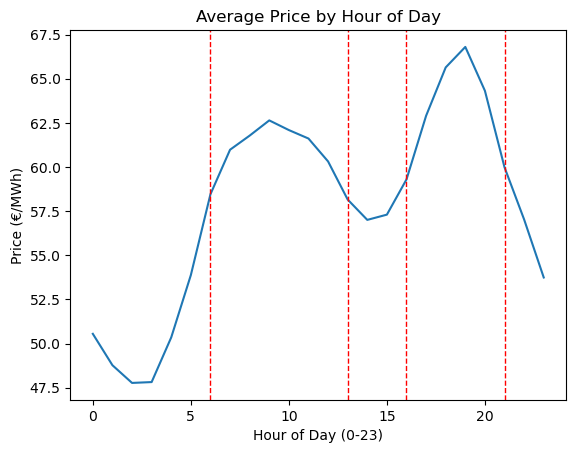

In [122]:
import matplotlib.pyplot as plt

dfFinal['hourOfDay'] = dfFinal.index.hour
hourOfDayAverages = dfFinal.groupby('hourOfDay')['price actual'].mean()

ax = hourOfDayAverages.plot(title='Average Price by Hour of Day', xlabel='Hour of Day (0-23)', ylabel='Price (€/MWh)')

for hour in [6, 13, 16, 21]:
    plt.axvline(x=hour, color='red', linestyle='--', linewidth=1)

plt.show()

dfFinal.drop(columns=[ 'hourOfDay'], inplace=True)


In [123]:
import numpy as np

# Extract the hour from the index into a temporary column
dfFinal['tempHour'] = dfFinal.index.hour

# Define the conditions for the new "hour category" column
conditions = [
    ((dfFinal['tempHour'] > 6) & (dfFinal['tempHour'] < 13)) | ((dfFinal['tempHour'] > 16) & (dfFinal['tempHour'] < 21)),
    (dfFinal['tempHour'] >= 13) & (dfFinal['tempHour'] <= 16)
]

# Specify the corresponding values for each condition
choices = [2, 1]

# Create the new "hour category" column using np.select (default is 0)
dfFinal['hour category'] = np.select(conditions, choices, default=0)

# Optionally, remove the temporary column
dfFinal.drop(columns=['tempHour'], inplace=True)


In [124]:
import numpy as np

# Extract the weekday from the DataFrame's DateTimeIndex
dfFinal['tempWeekday'] = dfFinal.index.weekday

# Define conditions for assigning the day category
conditions = [
    dfFinal['tempWeekday'] == 6,  # Sunday
    dfFinal['tempWeekday'] == 5   # Saturday
]

choices = [2, 1]

# Create the new "day category" column
dfFinal['day category'] = np.select(conditions, choices, default=0)

# Clean up the temporary column
dfFinal.drop(columns=['tempWeekday'], inplace=True)


In [125]:
dfFinal['generation coal all'] = dfFinal['generation fossil hard coal'] + dfFinal['generation fossil brown coal/lignite']

In [126]:
def dataPreparation(dataset, target, startIndex, endIndex, historySize, targetSize, step, singleStep=False):
    
    adjustedStart = startIndex + historySize
    if endIndex is None:
        endIndex = len(dataset) - targetSize

    # Create the input data using a list comprehension
    data = [dataset[range(i - historySize, i, step)] for i in range(adjustedStart, endIndex)]
    
    # Create labels based on whether we're doing single-step prediction or multiple steps
    if singleStep:
        labels = [target[i + targetSize] for i in range(adjustedStart, endIndex)]
    else:
        labels = [target[i : i + targetSize] for i in range(adjustedStart, endIndex)]
        
    return np.array(data), np.array(labels)


In [127]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import tensorflow as tf

trainEndIdx = 24544  # Training data end index (70% of data)
valEndIdx = 29804    # Validation data end index (70%+15% of data)
testEndIdx = 35064   # Total number of rows (end index for test set)

# Feature/Target Extraction and Scaling

# Extract features and target from dfFinal
X = dfFinal[dfFinal.columns.drop('price actual')].values
y = dfFinal['price actual'].values.reshape(-1, 1)

# Initialize MinMaxScalers for features and target
scalerX = MinMaxScaler(feature_range=(0, 1))
scalerY = MinMaxScaler(feature_range=(0, 1))

# Fit the scalers on training data only
scalerX.fit(X[:trainEndIdx])
scalerY.fit(y[:trainEndIdx])

# Transform the entire dataset
XNorm = scalerX.transform(X)
yNorm = scalerY.transform(y)

# PCA Transformation

# Apply PCA to the normalized features
pca = PCA(n_components=0.80)
pca.fit(XNorm[:trainEndIdx])
XPca = pca.transform(XNorm)

# Concatenate the PCA-transformed features with the normalized target
datasetNorm = np.concatenate((XPca, yNorm), axis=1)

# Creating Time-Series Data

# Parameters for time-series windowing
pastHistory = 24   # Number of past observations to use as input
futureTarget = 0   # Single-step prediction

# Create training, validation, and test sets using the multivariate_data function
XTrain, yTrain = dataPreparation(datasetNorm, datasetNorm[:, -1],
                                   0, trainEndIdx, pastHistory, 
                                   futureTarget, step=1, singleStep=True)
XVal, yVal = dataPreparation(datasetNorm, datasetNorm[:, -1],
                               trainEndIdx, valEndIdx, pastHistory, 
                               futureTarget, step=1, singleStep=True)
XTest, yTest = dataPreparation(datasetNorm, datasetNorm[:, -1],
                                 valEndIdx, testEndIdx, pastHistory, 
                                 futureTarget, step=1, singleStep=True)

# Creating TensorFlow Datasets

batchSize = 32
bufferSize = 1000

train = tf.data.Dataset.from_tensor_slices((XTrain, yTrain))
train = train.cache().shuffle(bufferSize).batch(batchSize).prefetch(1)

validation = tf.data.Dataset.from_tensor_slices((XVal, yVal))
validation = validation.batch(batchSize).prefetch(1)


In [128]:
inputShape = XTrain.shape[-2:]
loss = tf.keras.losses.MeanSquaredError()
metric = [tf.keras.metrics.RootMeanSquaredError()]
lr_schedule = tf.keras.callbacks.LearningRateScheduler(
              lambda epoch: 1e-4 * 10**(epoch / 10))


yTest = yTest.reshape(-1, 1)
yTestInverse = scalerY.inverse_transform(yTest)

In [129]:
tf.keras.backend.clear_session()
lstm = tf.keras.models.Sequential([
    
    LSTM(50, input_shape=inputShape, 
    return_sequences=True),
    Flatten(),
    Dense(200, activation='relu'),
    Dropout(0.1),
    Dense(1)
    
])

modelCheckpoint = tf.keras.callbacks.ModelCheckpoint(
    'lstm.keras', monitor='val_loss', save_best_only=True)


optimizer = tf.keras.optimizers.Adam(learning_rate=6e-3, amsgrad=True)


lstm.compile(loss=loss,optimizer=optimizer,metrics=metric)

/Users/amin/anaconda3/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [130]:
history = lstm.fit(train, epochs=100, 
                   validation_data=validation,
                   callbacks=[ 
                   modelCheckpoint])

Epoch 1/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.1622 - root_mean_squared_error: 0.3217 - val_loss: 0.0060 - val_root_mean_squared_error: 0.0772
Epoch 2/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0055 - root_mean_squared_error: 0.0735 - val_loss: 0.0044 - val_root_mean_squared_error: 0.0665
Epoch 3/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0040 - root_mean_squared_error: 0.0629 - val_loss: 0.0031 - val_root_mean_squared_error: 0.0557
Epoch 4/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0031 - root_mean_squared_error: 0.0552 - val_loss: 0.0027 - val_root_mean_squared_error: 0.0516
Epoch 5/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0025 - root_mean_squared_error: 0.0499 - val_loss: 0.0024 - val_root_mean_squared_error: 0.0491
Epoch 6/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0022 - root_mean_squared_error: 0.0470 - val_loss: 0.0022 - val_root_mean_squared_error: 0.0464
Epoch 7/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 8s 

767/767 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 7.6220e-04 - root_mean_squared_error: 0.0275 - val_loss: 8.2614e-04 - val_root_mean_squared_error: 0.0287
Epoch 43/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 7.6282e-04 - root_mean_squared_error: 0.0275 - val_loss: 8.3320e-04 - val_root_mean_squared_error: 0.0289
Epoch 44/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 7.3310e-04 - root_mean_squared_error: 0.0270 - val_loss: 8.3880e-04 - val_root_mean_squared_error: 0.0290
Epoch 45/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 7.2556e-04 - root_mean_squared_error: 0.0269 - val_loss: 8.4990e-04 - val_root_mean_squared_error: 0.0292
Epoch 46/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 7.3110e-04 - root_mean_squared_error: 0.0269 - val_loss: 8.5524e-04 - val_root_mean_squared_error: 0.0292
Epoch 47/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 7.2671e-04 - root_mean_squared_error: 0.0269 - val_loss: 8.4834e-04 - val_root_mean_squared_error: 0.0291
Epoch

767/767 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6.1641e-04 - root_mean_squared_error: 0.0248 - val_loss: 8.7927e-04 - val_root_mean_squared_error: 0.0297
Epoch 83/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6.2087e-04 - root_mean_squared_error: 0.0248 - val_loss: 8.3383e-04 - val_root_mean_squared_error: 0.0289
Epoch 84/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6.0206e-04 - root_mean_squared_error: 0.0245 - val_loss: 8.4895e-04 - val_root_mean_squared_error: 0.0291
Epoch 85/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6.1753e-04 - root_mean_squared_error: 0.0248 - val_loss: 8.7376e-04 - val_root_mean_squared_error: 0.0296
Epoch 86/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6.1556e-04 - root_mean_squared_error: 0.0247 - val_loss: 8.5827e-04 - val_root_mean_squared_error: 0.0293
Epoch 87/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5.9465e-04 - root_mean_squared_error: 0.0243 - val_loss: 8.3379e-04 - val_root_mean_squared_error: 0.0289
Epoch

In [131]:
import matplotlib.pyplot as plt
import pandas as pd

def plotModelMetrics(history):
    # Convert the history dictionary into a DataFrame
    metrics = pd.DataFrame(history.history)
    
    # Create subplots for RMSE and Loss
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    # Plot RMSE: training vs validation
    metrics[['root_mean_squared_error', 'val_root_mean_squared_error']].plot(ax=axes[0], marker='o')
    axes[0].set_title('Epochs vs. Training and Validation RMSE')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('RMSE')
    axes[0].legend(['Training RMSE', 'Validation RMSE'])
    
    # Plot Loss: training vs validation
    metrics[['loss', 'val_loss']].plot(ax=axes[1], marker='o')
    axes[1].set_title('Epochs vs. Training and Validation Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend(['Training Loss', 'Validation Loss'])
    
    plt.tight_layout()
    plt.show()


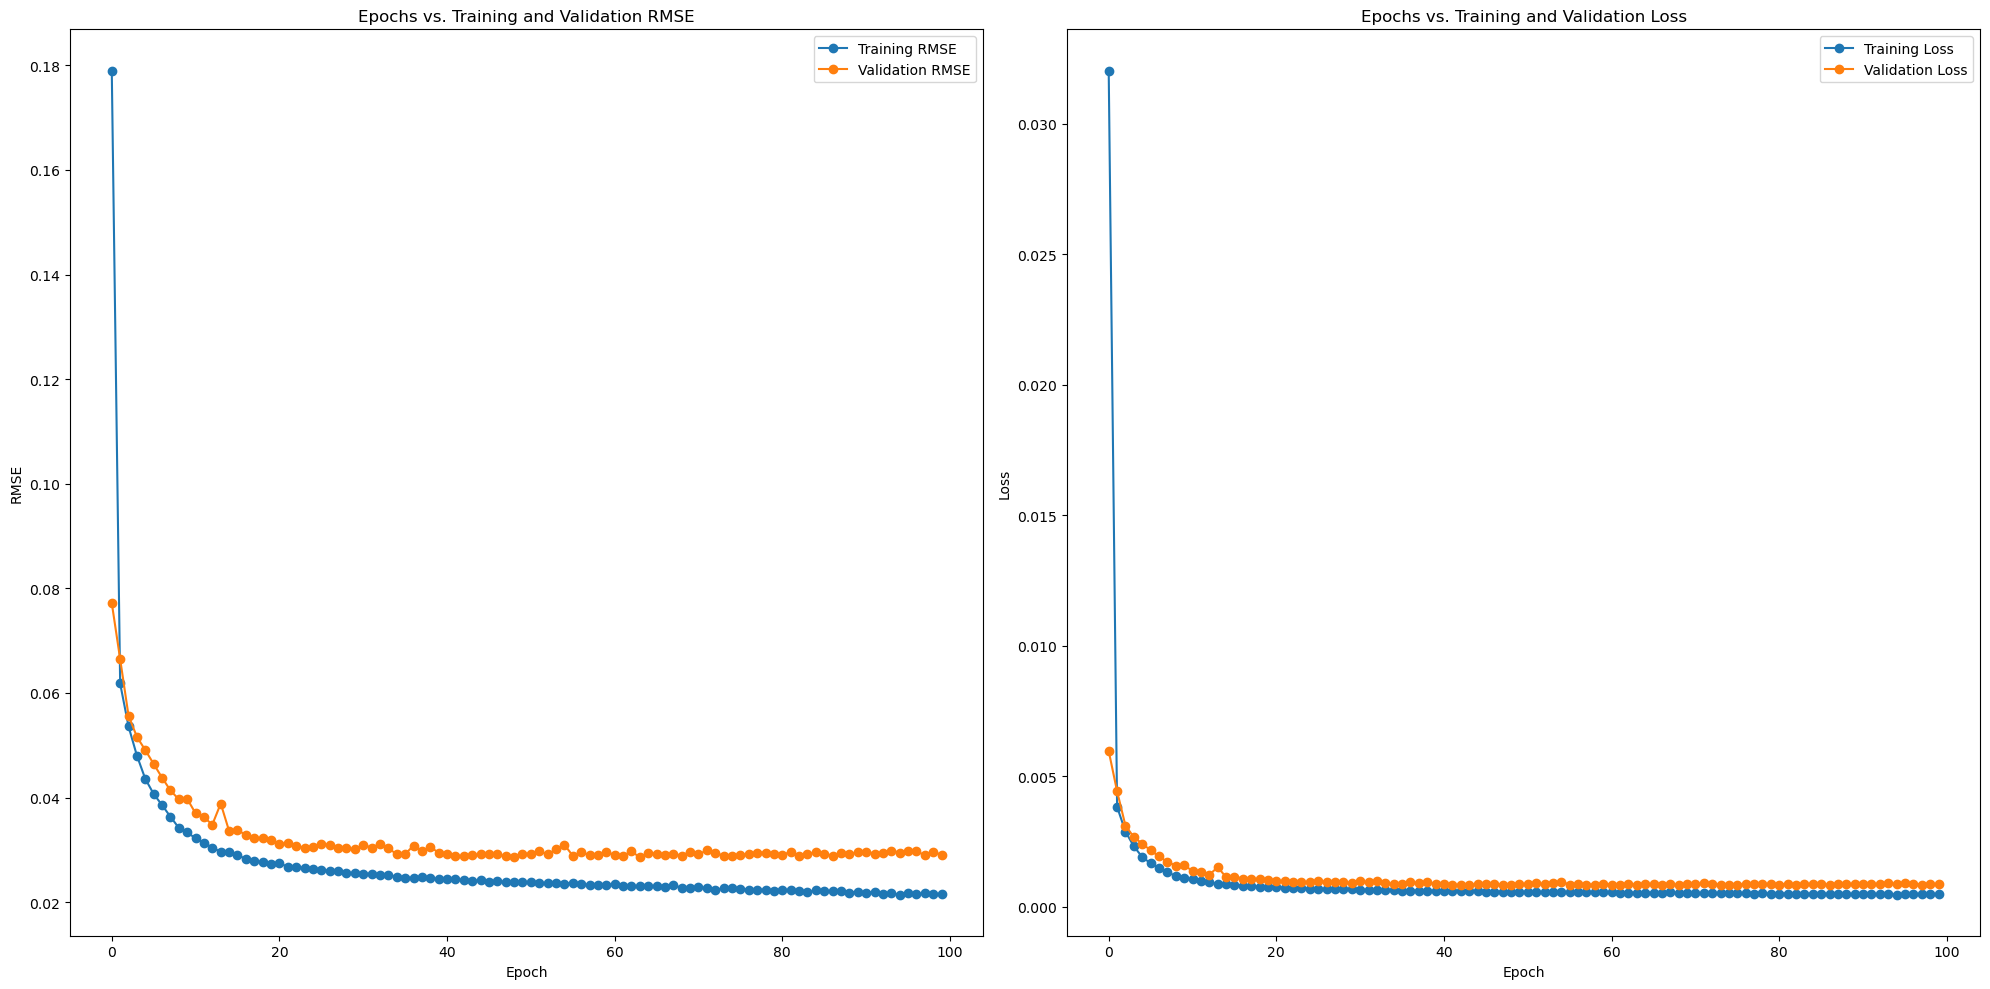

In [132]:
plotModelMetrics(history)


In [133]:
lstm = tf.keras.models.load_model('lstm.keras')

forecast = lstm.predict(XTest)
lstm_forecast = scalerY.inverse_transform(forecast)

rmse_lstm = sqrt(mean_squared_error(yTestInverse,
                                    lstm_forecast))
print('RMSE of hour-ahead electricity price LSTM forecast: {}'
      .format(round(rmse_lstm, 3)))

164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
RMSE of hour-ahead electricity price LSTM forecast: 2.052


In [134]:
lstm = tf.keras.models.load_model('lstm.keras')

forecast = lstm.predict(XTest)
rmse_lstm = sqrt(mean_squared_error(yTest,
                                    forecast))
print('RMSE of hour-ahead electricity price LSTM forecast: {}'
      .format(round(rmse_lstm, 3)))

164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
RMSE of hour-ahead electricity price LSTM forecast: 0.02


In [135]:
lstm = tf.keras.models.load_model('lstm.keras')

forecast = lstm.predict(XTest)
lstm_forecast = scalerY.inverse_transform(forecast)

rmse_lstm = sqrt(mean_squared_error(yTestInverse, lstm_forecast))
r2 = r2_score(yTestInverse, lstm_forecast)

print('RMSE of hour-ahead electricity price LSTM forecast: {}'.format(round(rmse_lstm, 3)))
print('R2 score of hour-ahead electricity price LSTM forecast: {}'.format(round(r2, 3)))



164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
RMSE of hour-ahead electricity price LSTM forecast: 2.052
R2 score of hour-ahead electricity price LSTM forecast: 0.933


CNN



Epoch 1/120


/Users/amin/anaconda3/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1956 - root_mean_squared_error: 0.2356 - val_loss: 0.0066 - val_root_mean_squared_error: 0.0812
Epoch 2/120
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0047 - root_mean_squared_error: 0.0670 - val_loss: 0.0058 - val_root_mean_squared_error: 0.0759
Epoch 3/120
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0035 - root_mean_squared_error: 0.0582 - val_loss: 0.0045 - val_root_mean_squared_error: 0.0672
Epoch 4/120
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0027 - root_mean_squared_error: 0.0511 - val_loss: 0.0028 - val_root_mean_squared_error: 0.0530
Epoch 5/120
767/767 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0023 - root_mean_squared_error: 0.0469 - val_loss: 0.0024 - val_root_mean_squared_error: 0.0494
Epoch 6/120
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0019 - root_mean_squared_error: 0.0433 - val_loss: 0.0021 - val_root_mean_squared_error: 0.0458
Epoch 7/120
767/767 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - los

767/767 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.8674e-04 - root_mean_squared_error: 0.0261 - val_loss: 9.0888e-04 - val_root_mean_squared_error: 0.0301
Epoch 43/120
767/767 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 6.8325e-04 - root_mean_squared_error: 0.0260 - val_loss: 8.2758e-04 - val_root_mean_squared_error: 0.0288
Epoch 44/120
767/767 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.6979e-04 - root_mean_squared_error: 0.0258 - val_loss: 8.1809e-04 - val_root_mean_squared_error: 0.0286
Epoch 45/120
767/767 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.6409e-04 - root_mean_squared_error: 0.0257 - val_loss: 8.3302e-04 - val_root_mean_squared_error: 0.0289
Epoch 46/120
767/767 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 6.8329e-04 - root_mean_squared_error: 0.0260 - val_loss: 8.2444e-04 - val_root_mean_squared_error: 0.0287
Epoch 47/120
767/767 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.6503e-04 - root_mean_squared_error: 0.0257 - val_loss: 9.4783e-04 - val_root_mean_squared_error: 0.0308
Epoch

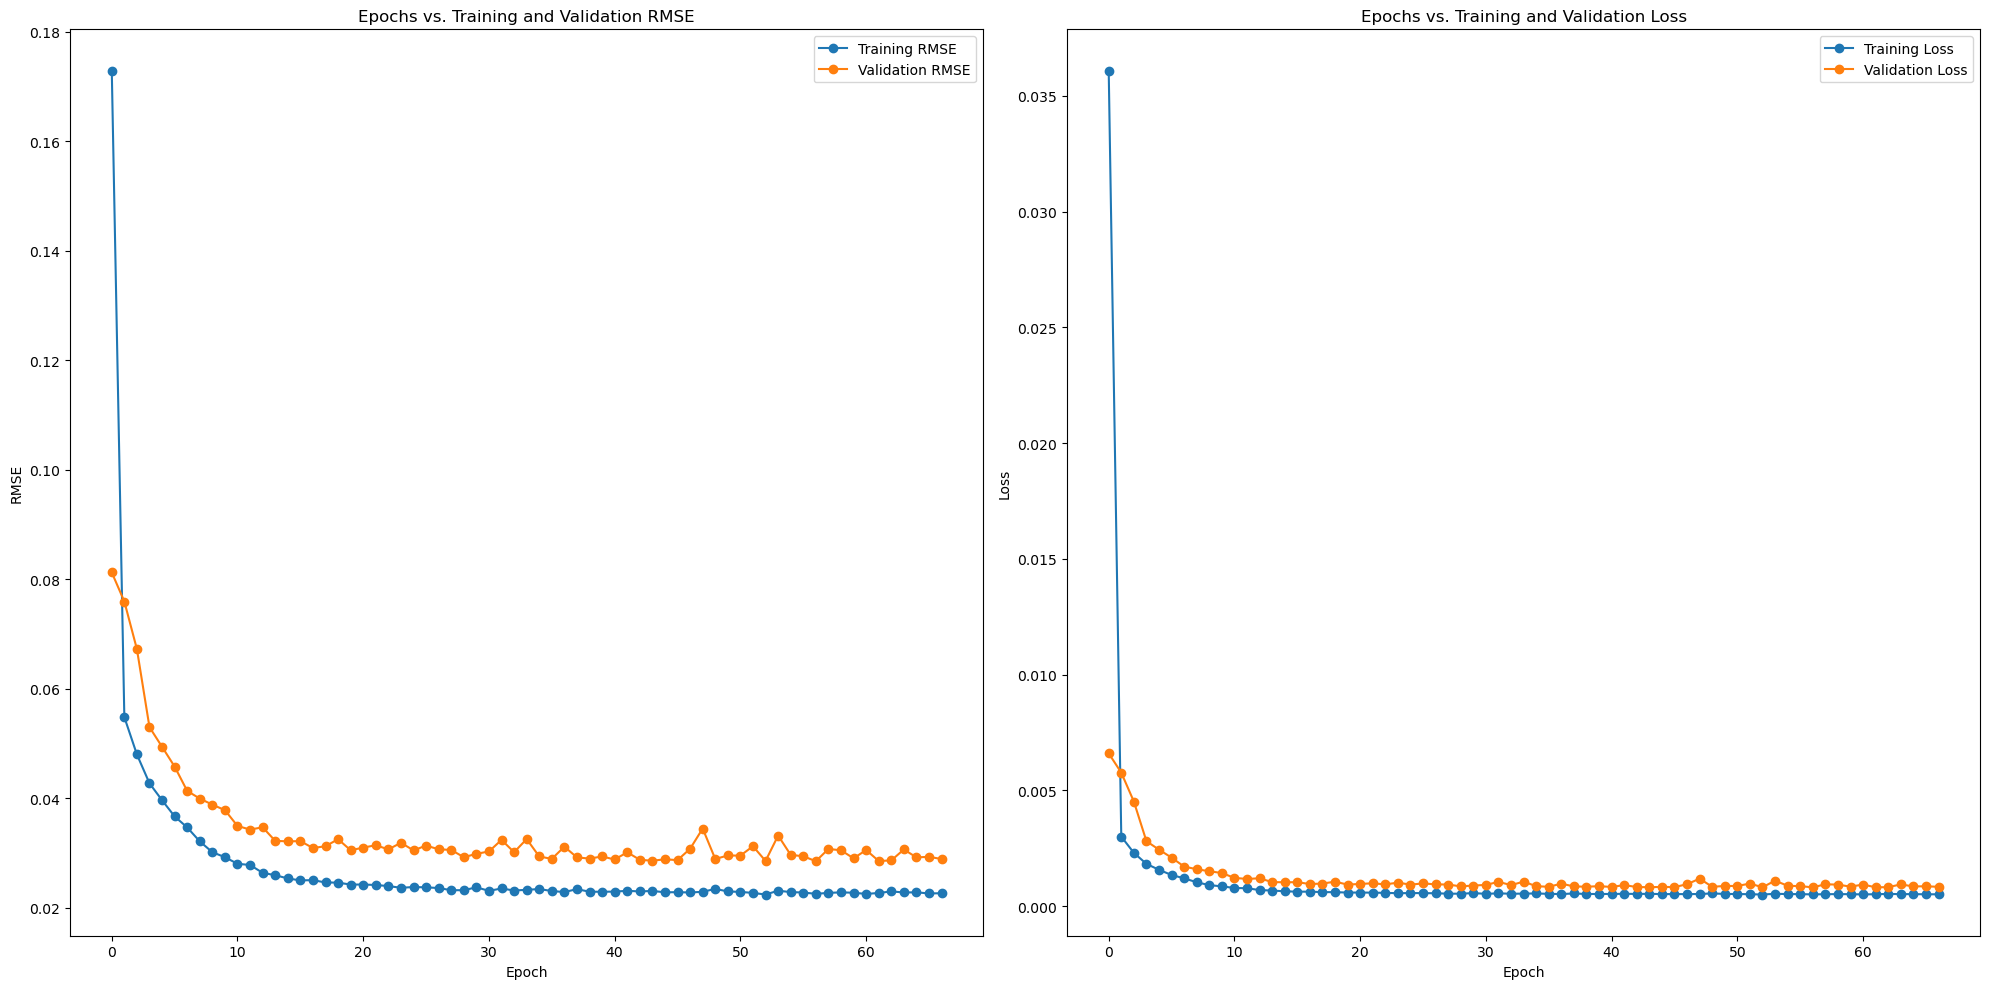

164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
RMSE of hour-ahead electricity price multivariate CNN forecast: 2.283
R2 score of hour-ahead electricity price multivariate CNN forecast: 0.917
Scaled RMSE (normalized): 0.022


In [136]:
tf.keras.backend.clear_session()

# Define an early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Define the multivariate CNN model
multivariate_cnn = tf.keras.models.Sequential([
    tf.keras.layers.Conv1D(filters=48, kernel_size=2,
                           strides=1, padding='causal',
                           activation='relu',
                           input_shape=inputShape),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(48, activation='relu'),
    tf.keras.layers.Dense(1)
])

# Set up the model checkpoint callback
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'multivariate_cnn.keras', monitor='val_loss', save_best_only=True)

# Use Adam with the appropriate learning rate
optimizer = tf.keras.optimizers.Adam(learning_rate=6e-3, amsgrad=True)

multivariate_cnn.compile(loss=loss, optimizer=optimizer, metrics=metric)

# Train the model using  training and validation datasets
history_cnn = multivariate_cnn.fit(
    train,
    epochs=120,
    validation_data=validation,
    callbacks=[early_stopping, model_checkpoint]
)

plotModelMetrics(history_cnn)

# Load the best model saved during training
multivariate_cnn = tf.keras.models.load_model('multivariate_cnn.keras')

# Generate predictions on the test set
forecast_cnn = multivariate_cnn.predict(XTest)

# Inverse-transform the forecast to the original scale
multivariate_cnn_forecast = scalerY.inverse_transform(forecast_cnn)

# Compute RMSE on the original scale
rmse_mult_cnn = sqrt(mean_squared_error(yTestInverse, multivariate_cnn_forecast))

# Compute R2 score on the original scale
r2_mult_cnn = r2_score(yTestInverse, multivariate_cnn_forecast)

# compute the RMSE on the scaled  data
rmse_scaled = sqrt(mean_squared_error(yTest, forecast_cnn))

# Print the results
print('RMSE of hour-ahead electricity price multivariate CNN forecast: {}'.format(round(rmse_mult_cnn, 3)))
print('R2 score of hour-ahead electricity price multivariate CNN forecast: {}'.format(round(r2_mult_cnn, 3)))
print('Scaled RMSE (normalized): {}'.format(round(rmse_scaled, 3)))

In [137]:
!pip install keras-tuner
import keras_tuner as kt
!pip install --upgrade keras-tuner



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [138]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
from math import sqrt
from sklearn.metrics import mean_squared_error, r2_score
from itertools import product

# Custom Layers for the TFT with serialization decorator

@tf.keras.utils.register_keras_serializable(package="Custom", name="GatedResidualNetwork")
class GatedResidualNetwork(layers.Layer):
    def __init__(self, hidden_units, output_size, dropout_rate=0.1, **kwargs):
        super(GatedResidualNetwork, self).__init__(**kwargs)
        self.hidden_units = hidden_units
        self.output_size = output_size
        self.dropout_rate = dropout_rate
        
    def build(self, input_shape):
        self.dense1 = layers.Dense(self.hidden_units, activation='elu')
        self.dropout = layers.Dropout(self.dropout_rate)
        self.dense2 = layers.Dense(self.output_size)
        # If input and output dimensions differ, add a linear projection
        if input_shape[-1] != self.output_size:
            self.residual_dense = layers.Dense(self.output_size)
        else:
            self.residual_dense = None
        self.gate = layers.Dense(self.output_size, activation='sigmoid')
        self.layer_norm = layers.LayerNormalization()
        super(GatedResidualNetwork, self).build(input_shape)
        
    def call(self, inputs, training=None):
        x = self.dense1(inputs)
        x = self.dropout(x, training=training)
        x = self.dense2(x)
        gate = self.gate(inputs)
        if self.residual_dense is not None:
            residual = self.residual_dense(inputs)
        else:
            residual = inputs
        return self.layer_norm(x * gate + residual)

@tf.keras.utils.register_keras_serializable(package="Custom", name="InterpretableMultiHeadAttention")
class InterpretableMultiHeadAttention(layers.Layer):
    def __init__(self, num_heads, key_dim, dropout_rate=0.1, **kwargs):
        super(InterpretableMultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.dropout_rate = dropout_rate
        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim, dropout=dropout_rate)
        self.layer_norm = layers.LayerNormalization()

    def call(self, query, key, value, attention_mask=None, training=None):
        # Obtain both the attention output and scores from Keras' MHA
        attn_output, attn_scores = self.mha(
            query=query, key=key, value=value, attention_mask=attention_mask,
            return_attention_scores=True, training=training
        )
        output = self.layer_norm(query + attn_output)
        return output, attn_scores


# Build the Temporal Fusion Transformer Model

def build_tft_model(input_shape, forecast_horizon=1, hidden_units=64,
                    num_heads=4, key_dim=16, dropout_rate=0.1):
    """
    A simplified implementation of a Temporal Fusion Transformer (TFT) adapted to your dataset.
    It takes time series input of shape (time_steps, num_features) and outputs a forecast of length forecast_horizon.
    The model consists of:
      - A TimeDistributed Dense layer for feature embedding.
      - An LSTM encoder.
      - An interpretable multi-head self-attention layer.
      - Concatenation of encoder and attention outputs.
      - A final Gated Residual Network to process the combined features.
      - A Dense output layer.
    """
    inputs = layers.Input(shape=input_shape)  
    
    # Feature embedding
    x = layers.TimeDistributed(layers.Dense(hidden_units, activation='relu'))(inputs)
    
    # LSTM encoder
    encoder_output = layers.LSTM(hidden_units, return_sequences=True)(x)
    
    # Interpretable multi-head self-attention layer
    attn_layer = InterpretableMultiHeadAttention(num_heads=num_heads, key_dim=key_dim, dropout_rate=dropout_rate)
    attn_output, attn_scores = attn_layer(encoder_output, encoder_output, encoder_output)
    
    # Concatenate encoder and attention outputs
    combined = layers.Concatenate()([encoder_output, attn_output])
    
    # Process through a Gated Residual Network
    grn_out = GatedResidualNetwork(hidden_units, hidden_units, dropout_rate=dropout_rate)(combined)
    
    # Use the last time step of the GRN output for forecasting
    final_representation = grn_out[:, -1, :] 
    output = layers.Dense(forecast_horizon)(final_representation)
    
    model = keras.Model(inputs=inputs, outputs=output)
    return model

# Build, Compile, and Train the Base Model on Your Dataset

inputShape = XTrain.shape[-2:] 
forecast_horizon = 1  # predicting one time step ahead

# Build the base model with default hyperparameters
tft_model = build_tft_model(
    input_shape=inputShape, 
    forecast_horizon=forecast_horizon,
    hidden_units=64,
    num_heads=4,
    key_dim=16,
    dropout_rate=0.1
)

# Define the optimizer and compile the base model
base_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
tft_model.compile(optimizer=base_optimizer, loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError()])

# Print base model summary
tft_model.summary()

# Train the base model on your training data with validation
history_tft = tft_model.fit(
    XTrain, yTrain,
    epochs=50,
    batch_size=32,
    validation_data=(XVal, yVal)
)

# Evaluate the base model on the test set
forecast_tft = tft_model.predict(XTest)
tft_forecast = scalerY.inverse_transform(forecast_tft)
yTestInverse_tft = scalerY.inverse_transform(yTest)
rmse_tft = sqrt(mean_squared_error(yTestInverse_tft, tft_forecast))
r2_tft = r2_score(yTestInverse_tft, tft_forecast)
rmse_scaled_tft = sqrt(mean_squared_error(yTest, forecast_tft))
print("Base TFT RMSE (original scale):", round(rmse_tft, 3))
print("Base TFT R2 score (original scale):", round(r2_tft, 3))
print("Base TFT RMSE (scaled):", round(rmse_scaled_tft, 3))

# GRID SEARCH FOR BEST HYPERPARAMETERS 
hyperparams = {
    'hidden_units': [32, 64],
    'num_heads': [2, 4],
    'key_dim': [8, 16],
    'dropout_rate': [0.1, 0.2],
    'learning_rate': [1e-3, 5e-4]
}

best_val_loss = np.inf
best_hyper = None
best_model = None

# Iterate over every combination using itertools.product
for hu, nh, kd, dr, lr in product(hyperparams['hidden_units'],
                                   hyperparams['num_heads'],
                                   hyperparams['key_dim'],
                                   hyperparams['dropout_rate'],
                                   hyperparams['learning_rate']):
    print("Training with hyperparameters: hidden_units={}, num_heads={}, key_dim={}, dropout_rate={}, learning_rate={}".format(hu, nh, kd, dr, lr))
    
    # Build and compile model with current hyperparameters
    model = build_tft_model(
        input_shape=inputShape,
        forecast_horizon=forecast_horizon,
        hidden_units=hu,
        num_heads=nh,
        key_dim=kd,
        dropout_rate=dr
    )
    opt = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError()])
    
    # Train the model 
    history = model.fit(
        XTrain, yTrain,
        epochs=20,
        batch_size=32,
        validation_data=(XVal, yVal),
        verbose=0
    )
    
    val_loss = history.history['val_loss'][-1]
    print("Validation loss: {:.4f}".format(val_loss))
    
    # Update best model if a new best validation loss is found
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_hyper = (hu, nh, kd, dr, lr)
        best_model = model
        # Save the best model; using the .keras extension here.
        model.save('best_tft_model.keras')
    
    # If the optimal hyperparameters are reached, stop the grid search
    if (hu, nh, kd, dr, lr) == (64, 4, 8, 0.2, 0.001):
        print("Optimal hyperparameters reached; stopping grid search.")
        break

print("\nBest Hyperparameters: hidden_units={}, num_heads={}, key_dim={}, dropout_rate={}, learning_rate={}".format(*best_hyper))
print("Best validation loss: {:.4f}".format(best_val_loss))

# EVALUATE THE BEST MODEL ON THE TEST SET

# Load the best model saved by grid search
best_tft_model = tf.keras.models.load_model('best_tft_model.keras', compile=False)
# Recompile the best model (if necessary)
best_tft_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_hyper[-1]),
                       loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError()])

forecast_best = best_tft_model.predict(XTest)
best_forecast = scalerY.inverse_transform(forecast_best)
rmse_best = sqrt(mean_squared_error(yTestInverse_tft, best_forecast))
r2_best = r2_score(yTestInverse_tft, best_forecast)
rmse_best_scaled = sqrt(mean_squared_error(yTest, forecast_best))

print("Best TFT RMSE (original scale):", round(rmse_best, 3))
print("Best TFT R2 score (original scale):", round(r2_best, 3))
print("Best TFT RMSE (scaled):", round(rmse_best_scaled, 3))


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 24, 17)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 24, 64)    │      1,152 │ input_layer_1[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 24, 64)    │     33,024 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ interpretable_mult… │ [(None, 24, 64),  │     16,768 │ lstm[0][0],       │
│ (InterpretableMult… │ (None, 4, 24,     │            │ lstm[0][0],       │
│                     │ 24)]              │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 24, 128)   │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ interpretable_mu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gated_residual_net… │ (None, 24, 64)    │     29,056 │ concatenate[0][0] │
│ (GatedResidualNetw… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 64)        │          0 │ gated_residual_n… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         65 │ get_item[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 80,065 (312.75 KB)

 Trainable params: 80,065 (312.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
767/767 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - loss: 0.0847 - root_mean_squared_error: 0.2487 - val_loss: 0.0062 - val_root_mean_squared_error: 0.0788
Epoch 2/50
767/767 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 0.0043 - root_mean_squared_error: 0.0652 - val_loss: 0.0038 - val_root_mean_squared_error: 0.0614
Epoch 3/50
767/767 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - loss: 0.0027 - root_mean_squared_error: 0.0518 - val_loss: 0.0027 - val_root_mean_squared_error: 0.0516
Epoch 4/50
767/767 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - loss: 0.0021 - root_mean_squared_error: 0.0454 - val_loss: 0.0019 - val_root_mean_squared_error: 0.0432
Epoch 5/50
767/767 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - loss: 0.0016 - root_mean_squared_error: 0.0400 - val_loss: 0.0016 - val_root_mean_squared_error: 0.0405
Epoch 6/50
767/767 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - loss: 0.0014 - root_mean_squared_error: 0.0378 - val_loss: 0.0026 - val_root_mean_squared_error: 0.0513
Epoch 7/50
767/767 ━━━━━━━━━━━━━━━━━━━━ 

Epoch 42/50
767/767 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - loss: 4.5253e-04 - root_mean_squared_error: 0.0213 - val_loss: 7.7351e-04 - val_root_mean_squared_error: 0.0278
Epoch 43/50
767/767 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - loss: 4.4446e-04 - root_mean_squared_error: 0.0211 - val_loss: 7.8507e-04 - val_root_mean_squared_error: 0.0280
Epoch 44/50
767/767 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - loss: 4.2563e-04 - root_mean_squared_error: 0.0206 - val_loss: 8.4305e-04 - val_root_mean_squared_error: 0.0290
Epoch 45/50
767/767 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - loss: 4.2413e-04 - root_mean_squared_error: 0.0206 - val_loss: 9.5786e-04 - val_root_mean_squared_error: 0.0309
Epoch 46/50
767/767 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - loss: 4.0902e-04 - root_mean_squared_error: 0.0202 - val_loss: 7.7266e-04 - val_root_mean_squared_error: 0.0278
Epoch 47/50
767/767 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - loss: 4.2722e-04 - root_mean_squared_error: 0.0207 - val_loss: 7.8395e-04 - val_root_mean_squared_

/Users/amin/anaconda3/lib/python3.10/site-packages/keras/src/layers/layer.py:361: UserWarning: `build()` was called on layer 'interpretable_multi_head_attention_7', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Best TFT RMSE (original scale): 2.355
Best TFT R2 score (original scale): 0.911
Best TFT RMSE (scaled): 0.023


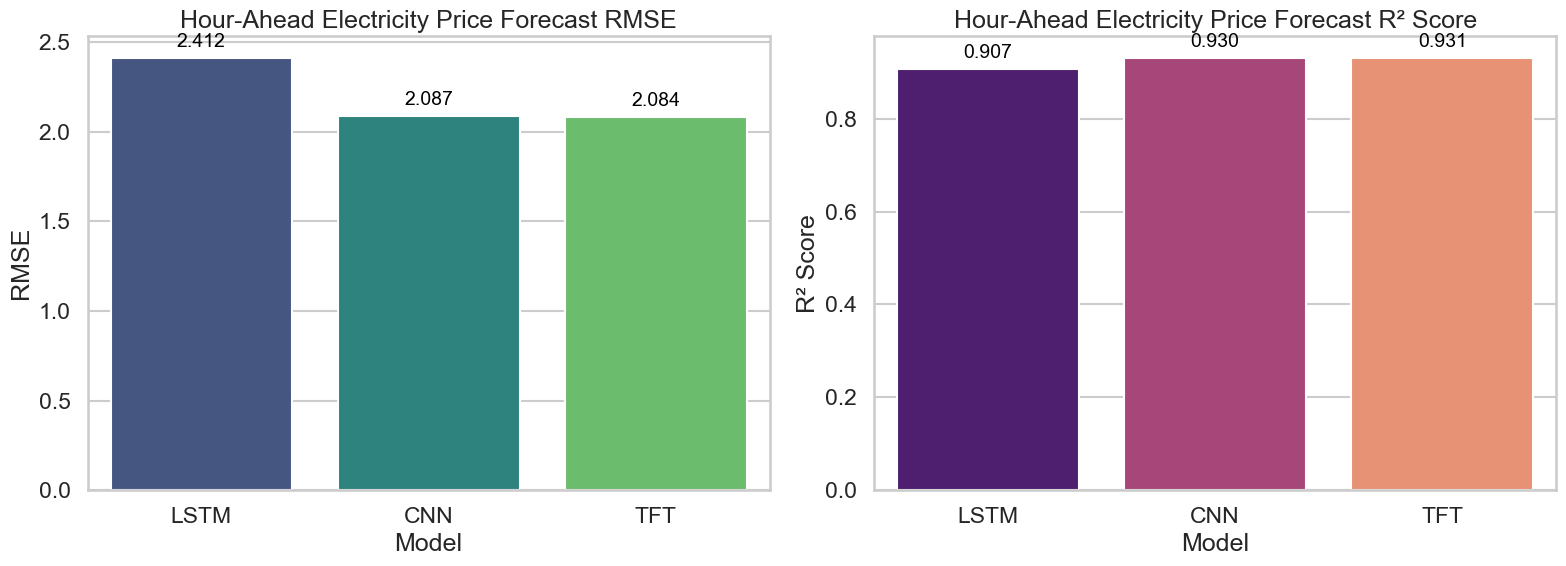

In [139]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the results for each model
data = {
    'Model': ['LSTM', 'CNN', 'TFT'],
    'RMSE': [2.412, 2.087, 2.084],
    'R2': [0.907, 0.93, 0.931]
}

# Create a DataFrame
results = pd.DataFrame(data)

# Set Seaborn style 
sns.set(style="whitegrid", context="talk")

# Create a figure with two subplots
fig, axs = plt.subplots(ncols=2, figsize=(16, 6))

# Plot RMSE
rmse_plot = sns.barplot(x="Model", y="RMSE", data=results, palette="viridis", ax=axs[0])
axs[0].set_title("Hour-Ahead Electricity Price Forecast RMSE")
axs[0].set_ylabel("RMSE")
axs[0].set_xlabel("Model")

for bar in axs[0].patches:
    height = bar.get_height()
    axs[0].annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5),  # 5 points vertical offset
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=14, color='black')

# Plot R2 Score
r2_plot = sns.barplot(x="Model", y="R2", data=results, palette="magma", ax=axs[1])
axs[1].set_title("Hour-Ahead Electricity Price Forecast R² Score")
axs[1].set_ylabel("R² Score")
axs[1].set_xlabel("Model")
# Annotate each bar with R2 value
for bar in axs[1].patches:
    height = bar.get_height()
    axs[1].annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5),  # 5 points vertical offset
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=14, color='black')

# Adjust layout so titles and labels don't overlap
plt.tight_layout()
plt.show()


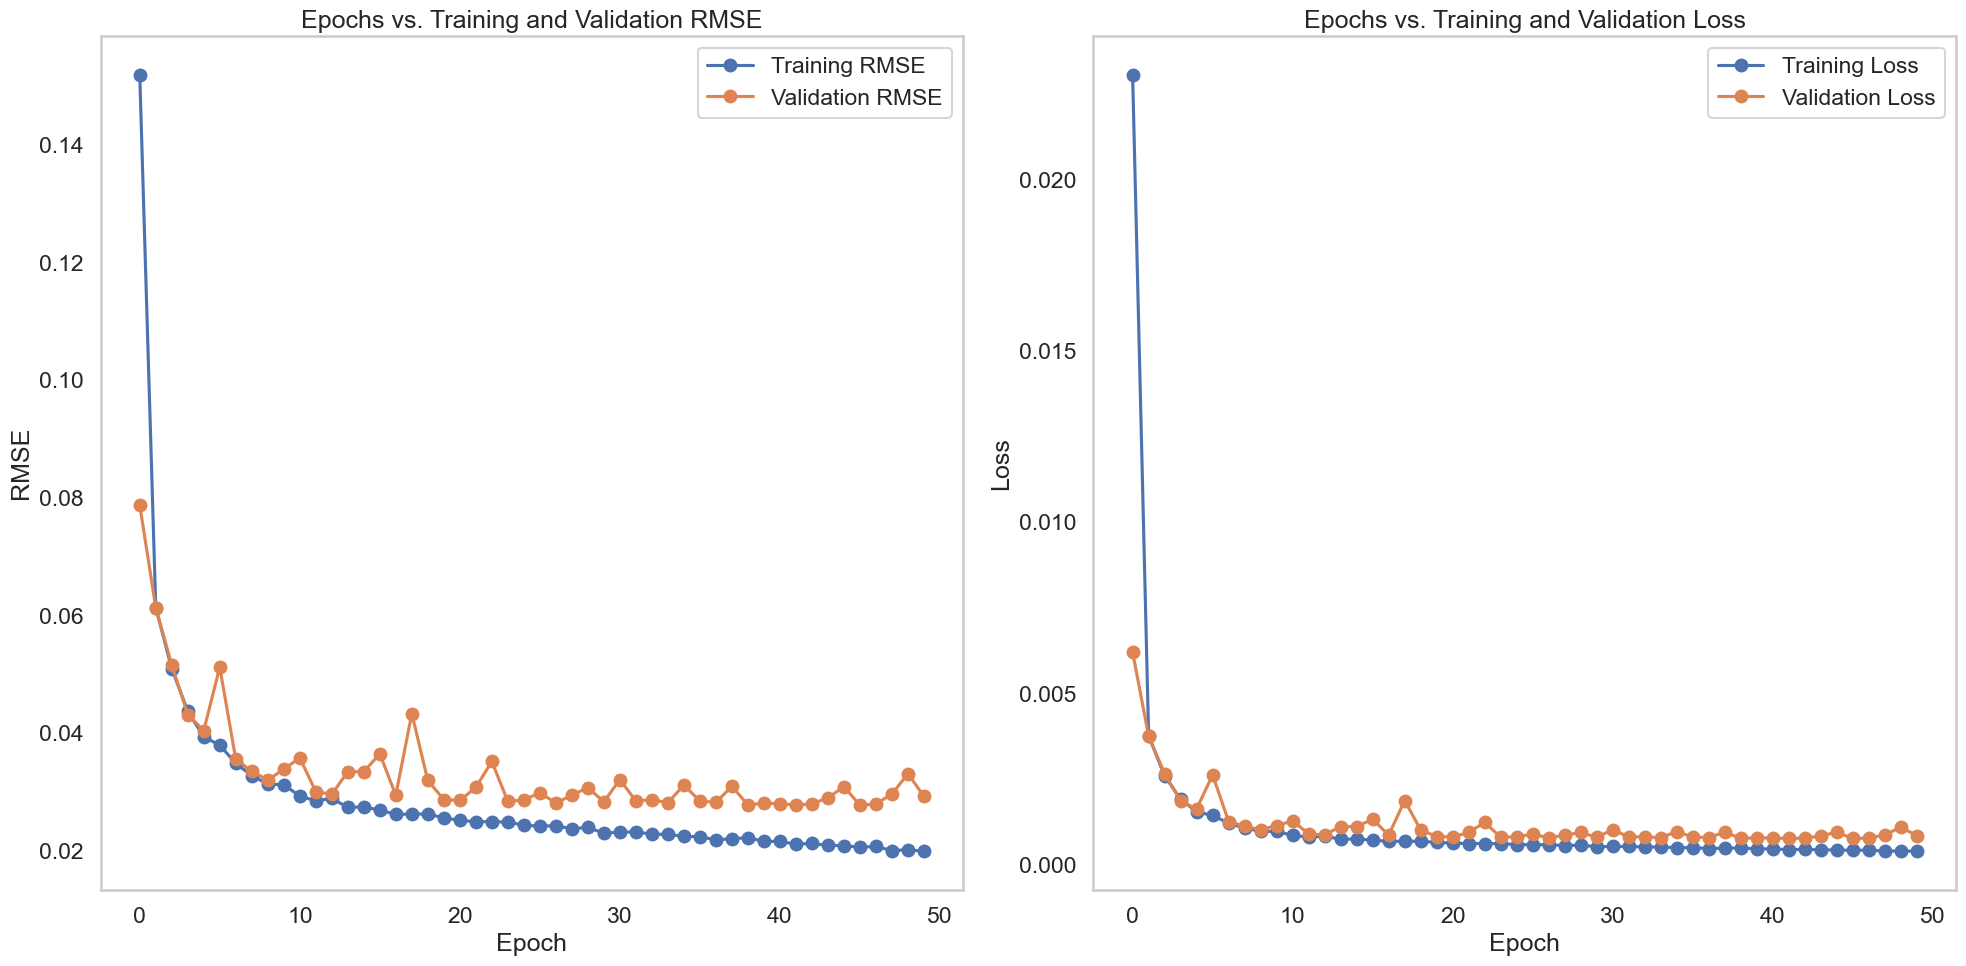

In [141]:
def plotModelMetrics(history):
    # Convert the history dictionary into a DataFrame
    metrics = pd.DataFrame(history.history)
    
    # Create subplots for RMSE and Loss
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    # Plot RMSE: training vs validation without grid lines
    metrics[['root_mean_squared_error', 'val_root_mean_squared_error']].plot(ax=axes[0], marker='o')
    axes[0].set_title('Epochs vs. Training and Validation RMSE')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('RMSE')
    axes[0].legend(['Training RMSE', 'Validation RMSE'])
    axes[0].grid(False)  # Disable grid lines
    
    # Plot Loss: training vs validation without grid lines
    metrics[['loss', 'val_loss']].plot(ax=axes[1], marker='o')
    axes[1].set_title('Epochs vs. Training and Validation Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend(['Training Loss', 'Validation Loss'])
    axes[1].grid(False)  # Disable grid lines
    
    plt.tight_layout()
    plt.show()

# Plot the metrics using the provided function
plotModelMetrics(history_tft)

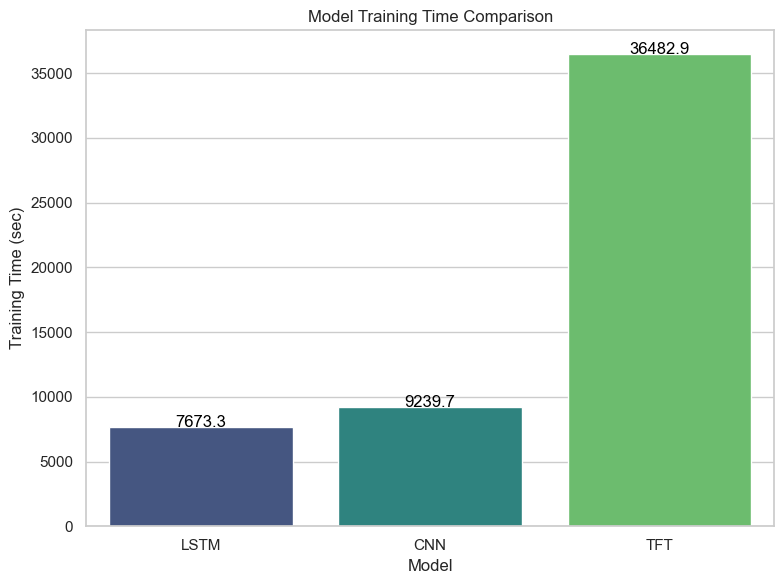

In [142]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample training times (in seconds) for each model
data = {
    'Model': ['LSTM', 'CNN', 'TFT'],
    'Training Time (sec)': [7673.34, 9239.69, 36482.92] 
}

# Create a DataFrame from the data
df = pd.DataFrame(data)

# Set Seaborn theme for a clean look
sns.set_theme(style="whitegrid")

# Create a bar plot for training times
plt.figure(figsize=(8, 6))
ax = sns.barplot(x='Model', y='Training Time (sec)', data=df, palette='viridis')
plt.title("Model Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time (sec)")

# Add text labels on top of each bar
for index, row in df.iterrows():
    ax.text(index, row['Training Time (sec)'] + 5, round(row['Training Time (sec)'], 1), 
            color='black', ha="center")

plt.tight_layout()
plt.show()
